In [8]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split

artifact = joblib.load("../models/final_churn_model.joblib")

final_model = artifact["pipeline"]
threshold = artifact["threshold"]
feature_columns = artifact["feature_columns"]

df = pd.read_csv("../data/processed/churn_modeling_dataset.csv")

X = df[feature_columns]
y = df["Churn Value"]

print("Model loaded")
print("Threshold:", threshold)
print("Features:", X.shape)

Model loaded
Threshold: 0.25
Features: (7043, 22)


In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

X_dev = pd.concat([X_train, X_val])

print("Test shape:", X_test.shape)

Test shape: (1057, 22)


In [10]:
import shap

### Generating SHAP values

In [11]:
preprocessor = final_model.named_steps["preprocessor"]
classifier = final_model.named_steps["classifier"]

X_background = X_dev.sample(
    n=100,
    random_state=42
)

X_explain = X_test.sample(
    n=200,
    random_state=42
)

background_transformed = preprocessor.transform(X_background)
explain_transformed = preprocessor.transform(X_explain)

feature_names = preprocessor.get_feature_names_out()

explainer = shap.LinearExplainer(
    classifier,
    background_transformed
)

shap_values = explainer(explain_transformed)

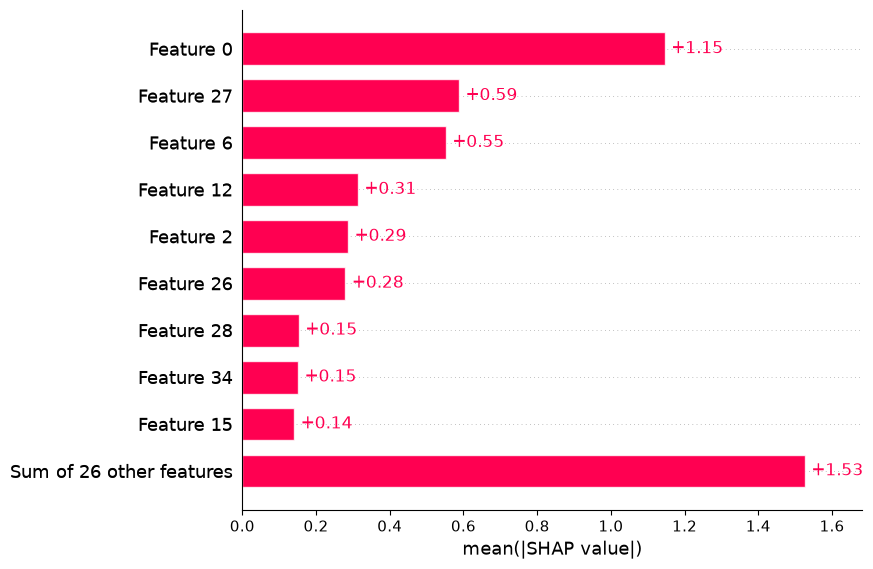

In [6]:
shap.plots.bar(shap_values)

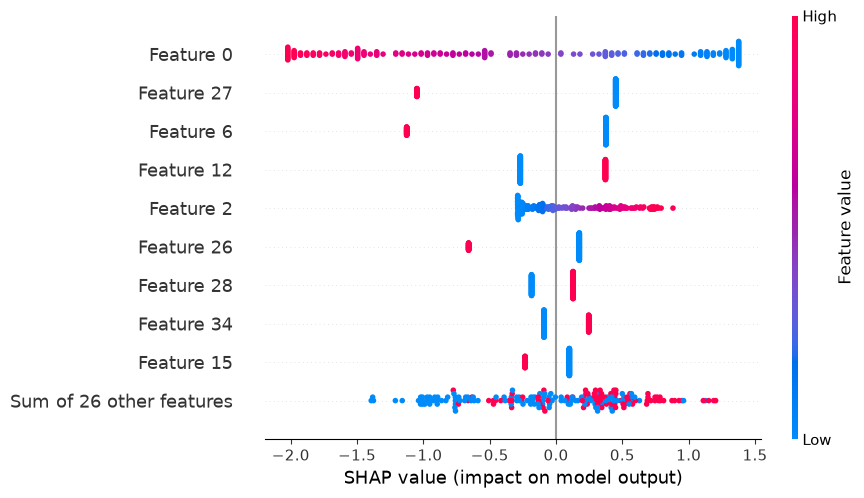

In [12]:
shap.plots.beeswarm(shap_values)